In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset berhasil diekstrak
Found 1000 files belonging to 10 classes.
Model berhasil dimuat!

MENGHITUNG INFERENCE TIME & STANDARD DEVIATION
Mean Latency : 96.25 ms
Std Deviation: 34.68 ms
Hasil untuk Naskah: 96.25 ± 34.68 ms

Mencari sampel Target Spot (Benar vs Salah)...


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


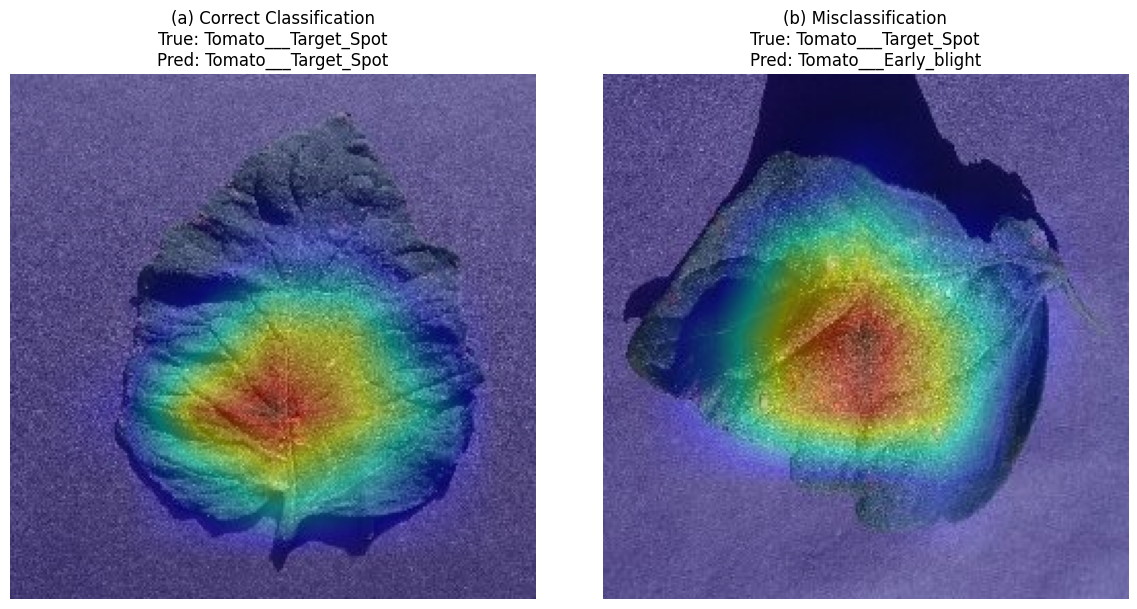


Gambar Grad-CAM tersimpan di: /content/drive/MyDrive/final_resnet50_2_gradcam_target_spot.png


In [3]:
import glob
import os
import time
import zipfile
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# =====================================================
# 1. LOAD DATASET & MODEL
# =====================================================
zip_path = "/content/drive/MyDrive/tomato.zip"
extract_path = "/content/tomato"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset berhasil diekstrak")

VAL_DIR = "/content/tomato/tomato/val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = val_ds.class_names
MODEL_PATH = "/content/drive/MyDrive/final_resnet50_2.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model berhasil dimuat!")

# =====================================================
# 2. MENGHITUNG LATENSI & STANDAR DEVIASI (1000 RUNS)
# =====================================================
print("\n" + "=" * 50)
print("MENGHITUNG INFERENCE TIME & STANDARD DEVIATION")
print("=" * 50)

for sample_images, _ in val_ds.take(1):
    single_image = sample_images[0:1]
    break

# Warm-up GPU/CPU
for _ in range(10):
    _ = model.predict(single_image, verbose=0)

latencies = []
for _ in range(1000):
    start_time = time.perf_counter()
    _ = model.predict(single_image, verbose=0)
    end_time = time.perf_counter()
    latencies.append((end_time - start_time) * 1000)

mean_latency = np.mean(latencies)
std_latency = np.std(latencies)

print(f"Mean Latency : {mean_latency:.2f} ms")
print(f"Std Deviation: {std_latency:.2f} ms")
print(f"Hasil untuk Naskah: {mean_latency:.2f} ± {std_latency:.2f} ms")


def generate_gradcam(img_array, model, class_idx):
    backbone = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            backbone = layer
            break

    if backbone is None:
        backbone = model
    last_conv_layer = None
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None:
        last_conv_layer = backbone.layers[-2]
    extractor = tf.keras.Model(
        inputs=backbone.inputs, outputs=last_conv_layer.output
    )
    with tf.GradientTape() as tape:
        conv_outputs = extractor(img_array)
        tape.watch(conv_outputs)
        x = conv_outputs
        backbone_idx = 0
        for i, layer in enumerate(model.layers):
            if layer == backbone:
                backbone_idx = i
                break

        for layer in model.layers[backbone_idx + 1 :]:
            x = layer(x)

        preds = x
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    guided_grads = tf.cast(grads > 0, "float32") * tf.cast(
        conv_outputs > 0, "float32"
    ) * grads

    weights = tf.reduce_mean(guided_grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(tf.multiply(weights, conv_outputs[0]), axis=-1)

    heatmap = cam.numpy()
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)
    return heatmap


def overlay_heatmap(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    superimposed_img = heatmap_color * alpha + img * (1 - alpha)
    return img, np.uint8(superimposed_img)


target_class_candidates = [n for n in class_names if "Target_Spot" in n]
if target_class_candidates:
    TARGET_CLASS_NAME = target_class_candidates[0]
    target_class_idx = class_names.index(TARGET_CLASS_NAME)
    target_dir = os.path.join(VAL_DIR, TARGET_CLASS_NAME)
    image_paths = glob.glob(os.path.join(target_dir, "*"))

    correct_img_path, correct_pred_label = None, None
    wrong_img_path, wrong_pred_label = None, None

    print("\nMencari sampel Target Spot (Benar vs Salah)...")
    for p in image_paths:
        img = tf.keras.utils.load_img(p, target_size=IMG_SIZE)
        img_arr = tf.keras.utils.img_to_array(img)
        img_arr_batch = np.expand_dims(img_arr, axis=0)

        preds = model.predict(img_arr_batch, verbose=0)
        pred_idx = np.argmax(preds[0])

        if pred_idx == target_class_idx and correct_img_path is None:
            correct_img_path = p
            correct_pred_label = class_names[pred_idx]
        elif pred_idx != target_class_idx and wrong_img_path is None:
            wrong_img_path = p
            wrong_pred_label = class_names[pred_idx]

        if correct_img_path and wrong_img_path:
            break

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    if correct_img_path:
        img = tf.keras.utils.load_img(correct_img_path, target_size=IMG_SIZE)
        img_arr = tf.keras.utils.img_to_array(img)
        img_arr_batch = np.expand_dims(img_arr, axis=0)

        heatmap = generate_gradcam(img_arr_batch, model, target_class_idx)
        _, cam_overlay = overlay_heatmap(correct_img_path, heatmap)
        axes[0].imshow(cam_overlay)
        axes[0].set_title(
            f"(a) Correct Classification\nTrue: {TARGET_CLASS_NAME}\nPred: {correct_pred_label}"
        )
        axes[0].axis("off")

    if wrong_img_path:
        img = tf.keras.utils.load_img(wrong_img_path, target_size=IMG_SIZE)
        img_arr = tf.keras.utils.img_to_array(img)
        img_arr_batch = np.expand_dims(img_arr, axis=0)

        heatmap = generate_gradcam(img_arr_batch, model, target_class_idx)
        _, cam_overlay = overlay_heatmap(wrong_img_path, heatmap)
        axes[1].imshow(cam_overlay)
        axes[1].set_title(
            f"(b) Misclassification\nTrue: {TARGET_CLASS_NAME}\nPred: {wrong_pred_label}"
        )
        axes[1].axis("off")

    plt.tight_layout()
    gradcam_save_path = (
        "/content/drive/MyDrive/final_resnet50_2_gradcam_target_spot.png"
    )
    plt.savefig(gradcam_save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\nGambar Grad-CAM tersimpan di: {gradcam_save_path}")

In [4]:
import os
import shutil
import time
import zipfile
import numpy as np
import tensorflow as tf

# =====================================================
# 1. LOAD DATASET & MODEL MOBILENETV2
# =====================================================
zip_path = "/content/drive/MyDrive/tomato.zip"
extract_path = "/content/tomato"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

VAL_DIR = "/content/tomato/tomato/val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

original_zip_path = "/content/drive/MyDrive/model_mobilenetv2_best.keras.zip"
target_keras_path = "/content/model_mobilenetv2_best.keras"

shutil.copyfile(original_zip_path, target_keras_path)
model = tf.keras.models.load_model(target_keras_path)
print("Model MobileNetV2 BERHASIL dimuat!")

# =====================================================
# 2. MENGHITUNG LATENSI & STANDAR DEVIASI (1000 RUNS)
# =====================================================
print("\n" + "=" * 50)
print("MENGHITUNG INFERENCE TIME & STANDARD DEVIATION (MOBILENETV2)")
print("=" * 50)

for sample_images, _ in val_ds.take(1):
    single_image = sample_images[0:1]
    break

# Warm-up GPU/CPU
for _ in range(10):
    _ = model.predict(single_image, verbose=0)

latencies = []
for _ in range(1000):
    start_time = time.perf_counter()
    _ = model.predict(single_image, verbose=0)
    end_time = time.perf_counter()
    latencies.append((end_time - start_time) * 1000)

mean_latency = np.mean(latencies)
std_latency = np.std(latencies)

print(f"Mean Latency (MobileNetV2) : {mean_latency:.2f} ms")
print(f"Std Deviation              : {std_latency:.2f} ms")
print(f"Hasil untuk Naskah         : {mean_latency:.2f} ± {std_latency:.2f} ms")

Found 1000 files belonging to 10 classes.
Model MobileNetV2 BERHASIL dimuat!

MENGHITUNG INFERENCE TIME & STANDARD DEVIATION (MOBILENETV2)
Mean Latency (MobileNetV2) : 83.88 ms
Std Deviation              : 19.33 ms
Hasil untuk Naskah         : 83.88 ± 19.33 ms


In [5]:
import os
import time
import zipfile
import numpy as np
import tensorflow as tf

# =====================================================
# 1. LOAD DATASET & MODEL EFFICIENTNET-B0
# =====================================================
zip_path = "/content/drive/MyDrive/tomato.zip"
extract_path = "/content/tomato"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

VAL_DIR = "/content/tomato/tomato/val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

MODEL_PATH = "/content/drive/MyDrive/model_efficientnet_awal.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model EfficientNet-B0 BERHASIL dimuat!")

# =====================================================
# 2. MENGHITUNG LATENSI & STANDAR DEVIASI (1000 RUNS)
# =====================================================
print("\n" + "=" * 50)
print("MENGHITUNG INFERENCE TIME & STANDARD DEVIATION (EFFICIENTNET-B0)")
print("=" * 50)

for sample_images, _ in val_ds.take(1):
    single_image = sample_images[0:1]
    break

# Warm-up GPU/CPU
for _ in range(10):
    _ = model.predict(single_image, verbose=0)

latencies = []
for _ in range(1000):
    start_time = time.perf_counter()
    _ = model.predict(single_image, verbose=0)
    end_time = time.perf_counter()
    latencies.append((end_time - start_time) * 1000)

mean_latency = np.mean(latencies)
std_latency = np.std(latencies)

print(f"Mean Latency (EfficientNet-B0) : {mean_latency:.2f} ms")
print(f"Std Deviation                  : {std_latency:.2f} ms")
print(f"Hasil untuk Naskah             : {mean_latency:.2f} ± {std_latency:.2f} ms")

Found 1000 files belonging to 10 classes.
Model EfficientNet-B0 BERHASIL dimuat!

MENGHITUNG INFERENCE TIME & STANDARD DEVIATION (EFFICIENTNET-B0)
Mean Latency (EfficientNet-B0) : 85.96 ms
Std Deviation                  : 18.63 ms
Hasil untuk Naskah             : 85.96 ± 18.63 ms
